Training data: 571 patients
Class distribution:
label
normal    426
rhd       145
Name: count, dtype: int64

Balancing dataset...
Training data: Normal=426, RHD=145
Loaded: Normal=426, RHD=145
Balanced: Normal=426, RHD=426

Creating augmented dataset...
Created 4260 augmented samples


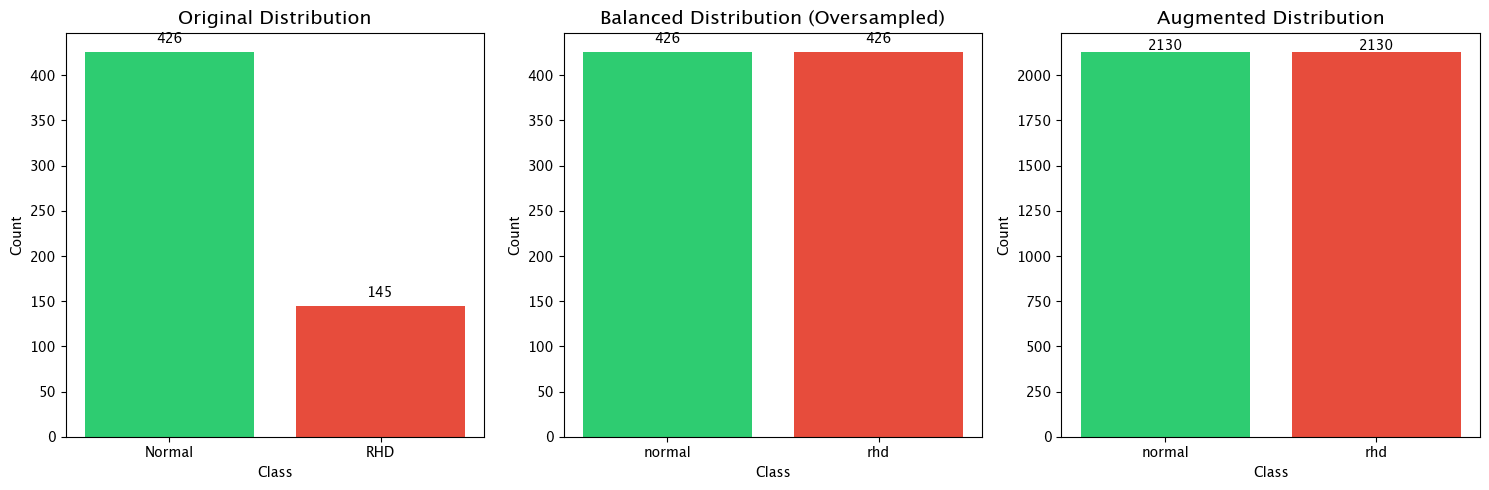


 DATA BALANCING SUMMARY
Original: Normal=426, RHD=145
  Imbalance ratio: 2.94:1
Balanced: Normal=426, RHD=426
Augmented total: 4260 samples
Combined total: 5112 samples

Data preparation complete!
Balanced data: 852 samples
Augmented data: 4260 samples
Combined: 5112 samples
Data saved to: ../data/balanced/mitral_valve


In [2]:
# data_balancing.ipynb
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/processed/mitral_valve'
OUTPUT_PATH = '../data/balanced/mitral_valve'
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'normal'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'rhd'), exist_ok=True)

# Create augmented directories
os.makedirs(os.path.join(OUTPUT_PATH, 'augmented', 'normal'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'augmented', 'rhd'), exist_ok=True)

def time_shift(signal, shift_ms, fs):
    """Shift signal in time"""
    shift_samples = int(shift_ms * fs / 1000)
    if shift_samples > 0:
        signal = np.pad(signal, (shift_samples, 0), mode='constant')[:-shift_samples]
    else:
        signal = np.pad(signal, (0, -shift_samples), mode='constant')[-shift_samples:]
    return signal

def add_gaussian_noise(signal, noise_level=0.005):
    """Add Gaussian noise to signal"""
    noise = np.random.normal(0, noise_level, len(signal))
    return signal + noise

def time_stretch(signal, rate):
    """Time stretch the signal"""
    return librosa.effects.time_stretch(signal, rate=rate)

def pitch_shift(signal, sr, n_steps):
    """Pitch shift the signal"""
    return librosa.effects.pitch_shift(signal, sr=sr, n_steps=n_steps)

def augment_signal(signal, fs):
    """Apply multiple augmentations to create variations"""
    augmented_signals = []
    
    # Original signal
    augmented_signals.append(('original', signal))
    
    # Time shift (small shifts)
    for shift in [10, -10, 20, -20]:
        shifted = time_shift(signal, shift, fs)
        augmented_signals.append((f'time_shift_{shift}ms', shifted))
    
    # Add noise
    for noise_level in [0.003, 0.005, 0.007]:
        noisy = add_gaussian_noise(signal, noise_level)
        augmented_signals.append((f'noise_{noise_level}', noisy))
    
    # Time stretch (subtle changes)
    for rate in [0.95, 1.05, 1.1]:
        stretched = time_stretch(signal, rate)
        # Resample to maintain original length
        if len(stretched) > len(signal):
            stretched = stretched[:len(signal)]
        elif len(stretched) < len(signal):
            stretched = np.pad(stretched, (0, len(signal) - len(stretched)), mode='constant')
        augmented_signals.append((f'stretch_{rate}', stretched))
    
    # Pitch shift
    for n_steps in [1, -1, 2, -2]:
        pitched = pitch_shift(signal, fs, n_steps)
        augmented_signals.append((f'pitch_{n_steps}', pitched))
    
    return augmented_signals

def balance_dataset(summary_df):
    """Balance the dataset using oversampling of minority class (RHD)"""
    
    # Filter out excluded patients - we only want Normal and RHD for training
    training_df = summary_df[summary_df['label'].isin(['normal', 'rhd'])].copy()
    print(f"Training data: Normal={len(training_df[training_df['label']=='normal'])}, RHD={len(training_df[training_df['label']=='rhd'])}")
    
    # Load all signals
    normal_signals = []
    rhd_signals = []
    
    for idx, row in training_df.iterrows():
        patient_id = row['patient_id']
        label = row['label']
        
        file_path = os.path.join(DATA_PATH, label, f"{patient_id}.wav")
        if os.path.exists(file_path):
            signal, fs = librosa.load(file_path, sr=None)
            if label == 'normal':
                normal_signals.append((patient_id, signal, fs))
            else:
                rhd_signals.append((patient_id, signal, fs))
    
    print(f"Loaded: Normal={len(normal_signals)}, RHD={len(rhd_signals)}")
    
    # Oversample RHD to match Normal count
    target_count = len(normal_signals)
    
    rhd_sampled = resample(
        rhd_signals,
        replace=True,  # Allow replacement for oversampling
        n_samples=target_count,
        random_state=42
    )
    
    normal_sampled = normal_signals.copy()
    
    print(f"Balanced: Normal={len(normal_sampled)}, RHD={len(rhd_sampled)}")
    
    # Save balanced data
    balanced_data = []
    
    # Save normal signals
    for patient_id, signal, fs in normal_sampled:
        output_path = os.path.join(OUTPUT_PATH, 'normal', f"{patient_id}.wav")
        sf.write(output_path, signal, fs)
        balanced_data.append({'patient_id': patient_id, 'label': 'normal'})
    
    # Save RHD signals
    for patient_id, signal, fs in rhd_sampled:
        output_path = os.path.join(OUTPUT_PATH, 'rhd', f"{patient_id}.wav")
        sf.write(output_path, signal, fs)
        balanced_data.append({'patient_id': patient_id, 'label': 'rhd'})
    
    return pd.DataFrame(balanced_data), len(normal_signals), len(rhd_signals)

def create_augmented_dataset(balanced_df, augment_per_class=4):
    """Create augmented dataset from balanced data"""
    
    augmented_data = []
    
    for idx, row in balanced_df.iterrows():
        patient_id = row['patient_id']
        label = row['label']
        
        file_path = os.path.join(OUTPUT_PATH, label, f"{patient_id}.wav")
        if not os.path.exists(file_path):
            continue
            
        signal, fs = librosa.load(file_path, sr=None)
        
        # Generate augmentations
        augmented_signals = augment_signal(signal, fs)
        
        # Save original
        orig_path = os.path.join(OUTPUT_PATH, 'augmented', label, f"{patient_id}_orig.wav")
        sf.write(orig_path, signal, fs)
        augmented_data.append({
            'patient_id': f"{patient_id}_orig",
            'label': label,
            'original_id': patient_id,
            'augmentation': 'original'
        })
        
        # Select augmentations to save
        selected_augs = ['time_shift_10ms', 'time_shift_-10ms', 
                        'noise_0.005', 'stretch_1.05', 
                        'pitch_1', 'pitch_-1']
        
        # Take only augment_per_class from the selected list
        selected_augs = selected_augs[:augment_per_class]
        
        for aug_name, aug_signal in augmented_signals:
            if aug_name == 'original':
                continue
                
            # Check if this augmentation should be saved
            should_save = False
            for selected in selected_augs:
                if selected in aug_name:
                    should_save = True
                    break
            
            if should_save:
                aug_path = os.path.join(OUTPUT_PATH, 'augmented', label, 
                                       f"{patient_id}_{aug_name}.wav")
                sf.write(aug_path, aug_signal, fs)
                augmented_data.append({
                    'patient_id': f"{patient_id}_{aug_name}",
                    'label': label,
                    'original_id': patient_id,
                    'augmentation': aug_name
                })
    
    print(f"Created {len(augmented_data)} augmented samples")
    return pd.DataFrame(augmented_data)

def visualize_distribution(original_normal, original_rhd, balanced_df, augmented_df):
    """Visualize class distribution and balancing"""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original distribution
    ax1 = axes[0]
    ax1.bar(['Normal', 'RHD'], [original_normal, original_rhd], 
            color=['#2ecc71', '#e74c3c'])
    ax1.set_title('Original Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Count')
    for i, v in enumerate([original_normal, original_rhd]):
        ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')
    
    # Balanced distribution
    ax2 = axes[1]
    balanced_counts = balanced_df['label'].value_counts()
    ax2.bar(balanced_counts.index, balanced_counts.values, 
            color=['#2ecc71', '#e74c3c'])
    ax2.set_title('Balanced Distribution (Oversampled)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Count')
    for i, v in enumerate(balanced_counts.values):
        ax2.text(i, v + 10, str(v), ha='center', fontweight='bold')
    
    # Augmented distribution
    ax3 = axes[2]
    augmented_counts = augmented_df['label'].value_counts()
    ax3.bar(augmented_counts.index, augmented_counts.values, 
            color=['#2ecc71', '#e74c3c'])
    ax3.set_title('Augmented Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Class')
    ax3.set_ylabel('Count')
    for i, v in enumerate(augmented_counts.values):
        ax3.text(i, v + 10, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    

    print("\n DATA BALANCING SUMMARY")

    print(f"Original: Normal={original_normal}, RHD={original_rhd}")
    print(f"  Imbalance ratio: {original_normal/original_rhd:.2f}:1")
    print(f"Balanced: Normal={balanced_counts['normal']}, RHD={balanced_counts['rhd']}")
    print(f"Augmented total: {len(augmented_df)} samples")
    print(f"Combined total: {len(balanced_df) + len(augmented_df)} samples")

if __name__ == "__main__":
    # Load summary from preprocessing
    summary_df = pd.read_csv(os.path.join(DATA_PATH, 'patient_summary.csv'))
    
    # Filter out excluded patients for training
    training_df = summary_df[summary_df['label'].isin(['normal', 'rhd'])].copy()
    print(f"Training data: {len(training_df)} patients")
    print("Class distribution:")
    print(training_df['label'].value_counts())
    
    # Balance dataset
    print("\nBalancing dataset...")
    balanced_df, normal_count, rhd_count = balance_dataset(summary_df)
    balanced_df.to_csv(os.path.join(OUTPUT_PATH, 'balanced_summary.csv'), index=False)
    
    # Create augmented dataset
    print("\nCreating augmented dataset...")
    augmented_df = create_augmented_dataset(balanced_df, augment_per_class=4)
    augmented_df.to_csv(os.path.join(OUTPUT_PATH, 'augmented_summary.csv'), index=False)
    
    # Combine balanced and augmented for training
    combined_df = pd.concat([balanced_df, augmented_df], ignore_index=True)
    combined_df.to_csv(os.path.join(OUTPUT_PATH, 'combined_summary.csv'), index=False)
    
    # Visualize
    visualize_distribution(normal_count, rhd_count, balanced_df, augmented_df)
    
    print(f"\nData preparation complete!")
    print(f"Balanced data: {len(balanced_df)} samples")
    print(f"Augmented data: {len(augmented_df)} samples")
    print(f"Combined: {len(combined_df)} samples")
    print(f"Data saved to: {OUTPUT_PATH}")